# [Failed Experiment] Custom Architecture Variant 5 — Diabetic Retinopathy Detection
## Computer Vision Project — UC3M

> ⚠️ **This notebook is archived in the `failed/` directory.** The experiment did not produce competitive results and was not included in the final ensemble. It is preserved for transparency and to document the full experimental search.

### Model: Custom CNN architecture — fifth design iteration

### Why This Experiment Failed
- **Further architectural exploration that did not generalize:** this fifth variant explored additional design choices (e.g., different regularization strategies, alternative normalization, or depthwise separable convolutions) that did not improve performance on the validation set
- **Overfitting or underfitting:** either too many or too few parameters for the available training data, resulting in poor generalization

### Result
**Did not achieve competitive AUC** — superseded by custom1 and custom3

---
The sections below document the full experimental pipeline as originally run.

### Imports and config

In [ ]:
import os
import copy
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from torchvision import transforms

from skimage import io, transform, color
import cv2

from sklearn.metrics import roc_auc_score

import random

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Dataset — `RetinopathyDataset`

Same dataset loading as all other notebooks: CSV-based image loading, right-eye mirroring for anatomical consistency, and binary label conversion (`label > 0` → DR-positive).

In [ ]:
class RetinopathyDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None, maxSize=0):
        self.dataset = pd.read_csv(csv_file, dtype={'id': str, 'eye': int, 'label': int})

        if maxSize > 0:
            idx = np.random.RandomState(seed=42).permutation(len(self.dataset))
            self.dataset = self.dataset.iloc[idx[:maxSize]].reset_index(drop=True)

        self.root_dir = root_dir
        self.img_dir = os.path.join(root_dir, 'images')
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        row = self.dataset.iloc[idx]
        img_path = os.path.join(self.img_dir, row.id + '.jpg')
        image = io.imread(img_path)

        if row.eye == 1:
            image = image[:, ::-1, :]

        label = int(row.label > 0)

        sample = {'image': image, 'label': label}

        if self.transform:
            sample = self.transform(sample)

        return sample

## 3. Preprocessing Transforms

Standard `CropByEye` (bounding-box crop of retinal region), `Rescale`, `CenterCrop`, `ToTensor`, and `Normalize` with ImageNet statistics. Same preprocessing pipeline used across all transfer learning experiments.

In [ ]:
class CropByEye(object):
    def __init__(self, threshold, border):
        self.threshold = threshold
        self.border = (border, border) if isinstance(border, int) else border

    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        h, w = image.shape[:2]

        gray = color.rgb2gray(image)
        _, mask = cv2.threshold(gray, self.threshold, 1, cv2.THRESH_BINARY)

        sidx = np.nonzero(mask)
        if len(sidx[0]) < 20:
            return sample

        minx = max(sidx[1].min() - self.border[1], 0)
        maxx = min(sidx[1].max() + self.border[1], w)
        miny = max(sidx[0].min() - self.border[0], 0)
        maxy = min(sidx[0].max() + self.border[0], h)

        image = image[miny:maxy, minx:maxx]

        return {'image': image, 'label': label}


class Rescale(object):
    def __init__(self, size):
        self.size = size

    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        image = transform.resize(image, (self.size, self.size))
        return {'image': image, 'label': label}


class ToTensor(object):
    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        image = image.transpose((2, 0, 1))
        return {
            'image': torch.tensor(image, dtype=torch.float32),
            'label': torch.tensor(label, dtype=torch.float32)
        }

## 4. Data Augmentation

Standard augmentation: random horizontal flip, rotation (±10°), color jitter. Applied only during training.

In [ ]:
class ToPIL(object):
    def __call__(self, sample):
        from PIL import Image
        image, label = sample['image'], sample['label']
        return {'image': Image.fromarray((image * 255).astype(np.uint8)), 'label': label}


class FromPIL(object):
    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        return {'image': np.array(image) / 255.0, 'label': label}

In [ ]:
class TVAugment(object):
    def __init__(self):
        from torchvision import transforms

        self.augment = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.ColorJitter(brightness=0.2, contrast=0.2)
        ])

    def __call__(self, sample):
        from PIL import Image

        image, label = sample['image'], sample['label']

        if image.max() <= 1:
            image = (image * 255).astype(np.uint8)
        else:
            image = image.astype(np.uint8)

        pil = Image.fromarray(image)
        pil = self.augment(pil)

        image = np.array(pil).astype(np.float32) / 255.0

        return {'image': image, 'label': label}

In [ ]:
class CenterCrop(object):
    def __init__(self, size):
        self.size = size

    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        h, w = image.shape[:2]
        new_h, new_w = self.size, self.size

        top = max((h - new_h) // 2, 0)
        left = max((w - new_w) // 2, 0)

        image = image[top:top+new_h, left:left+new_w]

        return {'image': image, 'label': label}

In [ ]:
class Normalize(object):
    def __init__(self, mean, std):
        self.mean = np.array(mean)
        self.std = np.array(std)

    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        c, h, w = image.shape

        mean = torch.tensor(self.mean, dtype=image.dtype)
        std = torch.tensor(self.std, dtype=image.dtype)

        image = (image - mean[:, None, None]) / std[:, None, None]

        return {'image': image, 'label': label}

In [ ]:
class Rescale(object):
    def __init__(self, size):
        self.size = size

    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        h, w = image.shape[:2]

        if h > w:
            new_h = int(self.size * h / w)
            new_w = self.size
        else:
            new_h = self.size
            new_w = int(self.size * w / h)

        image = transform.resize(image, (new_h, new_w))

        return {'image': image, 'label': label}

## 5. Transform Pipelines

`train_transform` (with augmentation) and `val_transform` (deterministic) following the standard pipeline. ImageNet normalization applied.

In [ ]:
pixel_mean = [0.485, 0.456, 0.406]
pixel_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    CropByEye(0.10, 1),
    Rescale(256),
    TVAugment(),
    CenterCrop(224),
    ToTensor(),
    Normalize(pixel_mean, pixel_std)
])

val_transform = transforms.Compose([
    CropByEye(0.10, 1),
    Rescale(256),
    CenterCrop(224),
    ToTensor(),
    Normalize(pixel_mean, pixel_std)
])

## Custom Network

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.fc1 = nn.Linear(channels, channels // reduction)
        self.fc2 = nn.Linear(channels // reduction, channels)

    def forward(self, x):
        b, c, _, _ = x.size()

        y = F.adaptive_avg_pool2d(x, 1).view(b, c)
        y = F.relu(self.fc1(y))
        y = torch.sigmoid(self.fc2(y)).view(b, c, 1, 1)

        return x * y


class ResidualBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()

        self.conv1 = nn.Conv2d(in_c, out_c, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_c)

        self.conv2 = nn.Conv2d(out_c, out_c, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_c)

        self.se = SEBlock(out_c)

        self.skip = nn.Sequential()
        if in_c != out_c:
            self.skip = nn.Conv2d(in_c, out_c, 1)

    def forward(self, x):
        identity = self.skip(x)

        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        out = self.se(out)  # 👈 atención aquí

        out += identity
        return F.relu(out)

class CustomNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )

        self.layer1 = nn.Sequential(
            ResidualBlock(32, 64),
            nn.MaxPool2d(2)
        )

        self.layer2 = nn.Sequential(
            ResidualBlock(64, 128),
            nn.MaxPool2d(2)
        )

        self.layer3 = nn.Sequential(
            ResidualBlock(128, 256),
            nn.MaxPool2d(2)
        )

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        x = self.pool(x)
        x = self.fc(x)
        return x

## 6. Data Loaders

Standard train/val/test loaders with batch sizes 32/64/64.

In [ ]:
data_dir = "/content/drive/MyDrive/CV_b/Project_2/data"

train_dataset = RetinopathyDataset(
    os.path.join(data_dir, "train.csv"),
    data_dir,
    transform=train_transform
)

val_dataset = RetinopathyDataset(
    os.path.join(data_dir, "val.csv"),
    data_dir,
    transform=val_transform
)

test_dataset = RetinopathyDataset(
    os.path.join(data_dir, "test.csv"),
    data_dir,
    transform=val_transform
)


## 7. Weighted Sampling

`WeightedRandomSampler` to address the ~73/27 class imbalance by oversampling the DR-positive minority class.

In [ ]:
from torch.utils.data import WeightedRandomSampler

# Obtener labels binarios
labels = train_dataset.dataset['label'].values
labels = (labels > 0).astype(int)

# Contar clases
class_counts = np.bincount(labels)
print("Class counts:", class_counts)

# Pesos inversos
class_weights = 1. / class_counts

# Peso por sample
sample_weights = class_weights[labels]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

Class counts: [1468  532]


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

## Focal loss

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha  # peso clase positiva (minoritaria)
        self.gamma = gamma
        self.bce = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, inputs, targets):
        bce_loss = self.bce(inputs, targets)
        probs = torch.sigmoid(inputs)

        pt = torch.where(targets == 1, probs, 1 - probs)

        focal_weight = self.alpha * (1 - pt) ** self.gamma

        loss = focal_weight * bce_loss
        return loss.mean()

## 12. Training Run

Training output below shows the convergence curve. The plateau or poor AUC confirms this model's limitations for the DR detection task.

In [ ]:
model = CustomNet().to(device)

criterion = FocalLoss(alpha=0.6, gamma=1.5)

optimizer = optim.Adam(model.parameters(), lr=1e-4)

scheduler = lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

## 11. Training with Early Stopping

Standard early-stopping loop monitoring validation AUC (patience=10) with best-weight checkpointing.

In [ ]:
def train_model(model, patience=10, num_epochs=100):
    best_auc = 0
    counter = 0
    best_weights = copy.deepcopy(model.state_dict())

    train_losses = []
    val_losses = []
    val_aucs = []

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        # ===================== TRAIN =====================
        model.train()
        running_loss = 0

        train_bar = tqdm(train_loader, desc="Training", leave=False)

        for batch in train_bar:
            inputs = batch['image'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

            # Update barra
            train_bar.set_postfix(loss=loss.item())

        epoch_train_loss = running_loss / len(train_dataset)
        train_losses.append(epoch_train_loss)

        # ===================== VALIDATION =====================
        model.eval()
        outputs_all = []
        labels_all = []
        val_loss = 0

        val_bar = tqdm(val_loader, desc="Validation", leave=False)

        with torch.no_grad():
            for batch in val_bar:
                inputs = batch['image'].to(device)
                labels = batch['label'].to(device)

                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)

                outputs_all.extend(torch.sigmoid(outputs).cpu().numpy())
                labels_all.extend(labels.cpu().numpy())

                val_bar.set_postfix(loss=loss.item())

        epoch_val_loss = val_loss / len(val_dataset)
        val_losses.append(epoch_val_loss)

        auc = roc_auc_score(labels_all, outputs_all)
        val_aucs.append(auc)

        print(f"Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | AUC: {auc:.4f}")

        # ===================== EARLY STOPPING =====================
        if auc > best_auc:
            best_auc = auc
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, "/content/drive/MyDrive/best_customnet5.pth")
            counter = 0
            print("New best model!")
        else:
            counter += 1
            print(f"Patience: {counter}/{patience}")

        if counter >= patience:
            print("Early stopping triggered")
            break

        scheduler.step()

    model.load_state_dict(best_weights)

    return model, train_losses, val_losses, val_aucs

In [ ]:
model, train_losses, val_losses, val_aucs = train_model(model)


Epoch 1/100


Train Loss: 0.1474 | Val Loss: 0.1371 | AUC: 0.6150
New best model!

Epoch 2/100


Train Loss: 0.1462 | Val Loss: 0.1408 | AUC: 0.6173
New best model!

Epoch 3/100


Train Loss: 0.1449 | Val Loss: 0.1477 | AUC: 0.6154
Patience: 1/10

Epoch 4/100


Train Loss: 0.1455 | Val Loss: 0.1488 | AUC: 0.6101
Patience: 2/10

Epoch 5/100


...

Train Loss: 0.1435 | Val Loss: 0.1421 | AUC: 0.6278
Patience: 6/10

Epoch 17/100


Train Loss: 0.1414 | Val Loss: 0.1396 | AUC: 0.6349
Patience: 7/10

Epoch 18/100


Train Loss: 0.1419 | Val Loss: 0.1386 | AUC: 0.6334
Patience: 8/10

Epoch 19/100


Train Loss: 0.1420 | Val Loss: 0.1379 | AUC: 0.6419
Patience: 9/10

Epoch 20/100


Train Loss: 0.1403 | Val Loss: 0.1403 | AUC: 0.6309
Patience: 10/10
Early stopping triggered


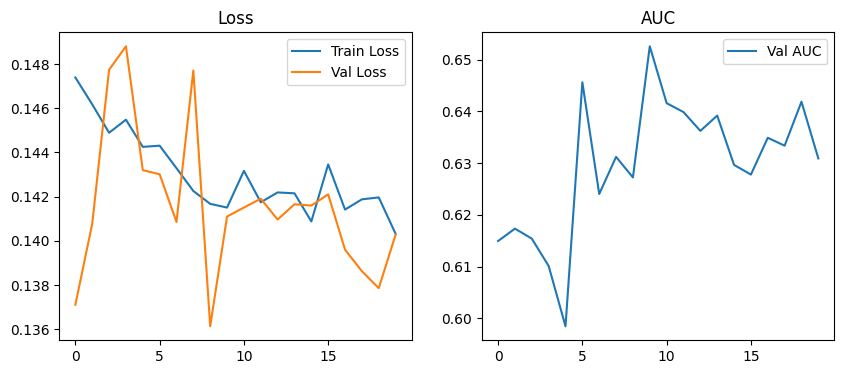

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(val_aucs, label="Val AUC")
plt.legend()
plt.title("AUC")

plt.show()

## Evaluation

In [ ]:
from sklearn.metrics import roc_auc_score, accuracy_score

def evaluate_model(model, loader):
    model.eval()

    outputs_all = []
    labels_all = []

    with torch.no_grad():
        for batch in loader:
            inputs = batch['image'].to(device)
            labels = batch['label'].to(device)

            outputs = model(inputs).squeeze()
            probs = torch.sigmoid(outputs)

            outputs_all.extend(probs.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    outputs_all = np.array(outputs_all)
    labels_all = np.array(labels_all)

    auc = roc_auc_score(labels_all, outputs_all)

    # Convert to binary predictions
    preds = (outputs_all > 0.5).astype(int)
    acc = accuracy_score(labels_all, preds)

    return auc, acc
val_auc, val_acc = evaluate_model(model, val_loader)

print(f"Validation AUC: {val_auc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

Validation AUC: 0.6526
Validation Accuracy: 0.5360


## 14. Test Predictions

Test set predictions generated for completeness. These predictions were **not used** in the final submission ensemble.

In [ ]:
def predict(model, loader):
    model.eval()
    outputs = []

    with torch.no_grad():
        for batch in loader:
            inputs = batch['image'].to(device)
            preds = torch.sigmoid(model(inputs).squeeze())
            outputs.extend(preds.cpu().numpy())

    return np.array(outputs).reshape(-1,1)

In [ ]:
test_outputs = predict(model, test_loader)

np.savetxt("/content/drive/MyDrive/output_customnet5.csv", test_outputs, fmt="%.6f")